# Aerosol testing

This notebook tests the backend setup for an atmosphere with aerosols only.

In [1]:
import eradiate
import seaborn as sns
from eradiate.contexts import KernelContext

import eradiate_disort as ed
from eradiate_disort.testing import TestMode, cases
from eradiate_disort.testing.util import Result, disort_reshape_pplane

plt = TestMode.plt()

eradiate.fresolver.prepend("../data")
eradiate.set_mode("ckd")
sns.set_theme(style="ticks")

_base_spp = TestMode.spp(tutorial=1_000, test=10_000)
SPP = _base_spp // 16 if eradiate.get_mode().is_ckd else _base_spp

exp = cases.aerosols(sza=30.0)
ctx = KernelContext()
exp.atmosphere.eval_radprops(ctx.si, optional_fields=True)

<xarray.Dataset> Size: 4kB
Dimensions:  (z_layer: 100)
Coordinates:
  * z_layer  (z_layer) float64 800B 0.5 1.5 2.5 3.5 4.5 ... 96.5 97.5 98.5 99.5
Data variables:
    sigma_t  (z_layer) float64 800B 0.0005 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    albedo   (z_layer) float64 800B 0.2089 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    sigma_a  (z_layer) float64 800B 0.0003956 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    sigma_s  (z_layer) float64 800B 0.0001044 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [2]:
results = {}
CASES = {
    "scattering": {
        "has_absorption": False,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "absorption": {
        "has_absorption": True,
        "has_scattering": False,
        "surface_reflectance": 1.0,
    },
    "full_black": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 0.0,
    },
    "full_white": {
        "has_absorption": True,
        "has_scattering": True,
        "surface_reflectance": 1.0,
    },
}

for case_id, kwargs in CASES.items():
    print(f"Processing case {case_id!r}")
    if case_id in results:
        continue

    result = Result()

    exp = cases.aerosols(**kwargs, backend="mitsuba")
    result.mitsuba = eradiate.run(exp, spp=SPP)["radiance"].squeeze()

    exp = cases.aerosols(**kwargs, backend="disort")
    backend = ed.EradiateDisortBackend()
    result.disort = disort_reshape_pplane(backend.run(exp).sel(z=1e5))

    results[case_id] = result

Processing case 'scattering'


0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

Processing case 'absorption'


0/16|          | 00:00, ETA=?

...

0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

Processing case 'full_white'


0/16|          | 00:00, ETA=?

0/16|          | 00:00, ETA=?

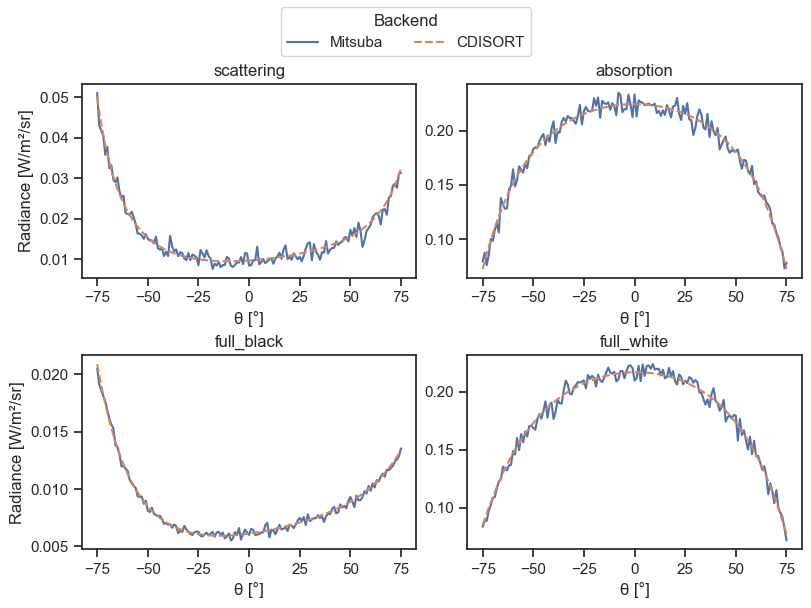

In [3]:
ncases = len(CASES)
ncols = 2
nrows = ncases // ncols + min(ncases % ncols, 1)

fig, axs = plt.subplots(
    nrows, ncols, figsize=(4 * ncols, 3 * nrows), layout="constrained", squeeze=False
)

for i, case_id in enumerate(CASES.keys()):
    irow = i // ncols
    icol = i % ncols
    ax = axs.ravel()[i]
    result = results[case_id]

    ax.plot(result.mitsuba["vza"], result.mitsuba, label="Mitsuba" if i == 0 else None)
    ax.plot(
        result.disort["vza"],
        result.disort,
        label="CDISORT" if i == 0 else None,
        ls="--",
    )

    ax.set_title(case_id)
    ax.set_xlabel("θ [°]")
    if icol == 0:
        ax.set_ylabel("Radiance [W/m²/sr]")

else:
    while (i := i + 1) < axs.size:
        ax = axs.ravel()[i]
        ax.set_axis_off()

fig.legend(title="Backend", ncol=2, loc="outside upper center")

plt.show()